# Домашнее задание 3 - Проверка статистических гипотез и параметрические критерии

**ВАЖНО: Обязательно для каждой задачи строим график и показываем куда попадает наше значение, если в задаче нужно проверить статистическую гипотезу**
\
**При отсутствии графиков возможна полная потеря баллов за задание**

In [ ]:
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from enum import Enum, auto
from abc import ABC, abstractmethod
from typing import Tuple, NamedTuple

Напишем классы для тестирования:

In [ ]:
class Sides(Enum):
    LEFT = auto(),
    RIGHT = auto(),
    COMMON = auto()

class Crits(NamedTuple):
    left: float
    right: float

In [ ]:
# Класс для получения результатов тестирования
class Tester(ABC):
    def __init__(self, distr: st.rv_continuous, side: Sides, alpha: float):
        self.distr = distr
        self.side = side
        self.alpha = alpha

    def _get_crits(self) -> Crits:
        match self.side:
            case Sides.LEFT:
                return Crits(left=self.distr.ppf(self.alpha), right=np.inf)
            case Sides.RIGHT:
                return Crits(left=-np.inf, right=self.distr.ppf(1 - self.alpha))
            case Sides.COMMON:
                return Crits(left=self.distr.ppf(self.alpha / 2), right=self.distr.ppf(1 - self.alpha / 2))

    def _get_p_value(self, stat: float) -> float:
        match self.side:
            case Sides.LEFT:
                return self.distr.cdf(stat)
            case Sides.RIGHT:
                return 1 - self.distr.cdf(stat)
            case Sides.COMMON:
                return 2 * (1 - self.distr.cdf(abs(stat)))

    def _get_rejection_and_stat_and_crits(self, stat: float) -> Tuple[bool, float, Crits]:
        crits = self._get_crits()
        print(f'Область внутри критических значений: [{crits.left:.4f}, {crits.right:.4f}]')

        p_value = self._get_p_value(stat)
        print(f'p-значение: {p_value:.5f}')

        is_rejected = False

        if (np.isnan(crits.left) or stat >= crits.left) and (np.isnan(crits.right) or stat <= crits.right):
            print('Не отклоняем нулевую гипотезу.')
        else:
            is_rejected = True
            print('Отклоняем нулевую гипотезу.')

        return is_rejected, stat, crits

    def _get_interval(self, mu: float, sigma: float) -> Crits:
      left = mu - sigma * self.distr.ppf(1 - self.alpha / 2)
      right = mu + sigma * self.distr.ppf(1 - self.alpha / 2)
      return Crits(left, right)

    # Тест для среднего
    def get_stats_for_mean(self, mu0: float, n: int, mu: float, sigma: float) -> Tuple[bool, float, Crits]:
        SE = sigma / np.sqrt(n)
        print(f'Стандартная ошибка (SE): {SE:.4f}')

        stat = (mu - mu0) / SE
        print(f'Статистика: {stat:.4f}')

        is_rejected, stat, crits = self._get_rejection_and_stat_and_crits(stat)
        interval = self._get_interval(mu, sigma)

        print(f"Доверительный интервал для среднего: [{interval.left:.4f}, {interval.right:.4f}]")
        return is_rejected, stat, crits

    # Тест для разности средних
    def get_stats_for_mean_diff(self, n1: int, mu1: float, sigma1: float, n2: int, mu2: float, sigma2: float) -> Tuple[bool, float, Crits]:
        df = n1 + n2 - 2
        sp2 = ((n1-1) * sigma1**2 + (n2-1) * sigma2**2) / df
        print(f'Объединенная выборочная дисперсия (sp^2): {sp2:.4f}')

        SE = np.sqrt(sp2 * (1/n1 + 1/n2))
        print(f'Стандартная ошибка (SE): {SE:.4f}')

        stat = (mu1 - mu2) / SE
        print(f'Cтатистика: {stat:.4f}')

        is_rejected, stat, crits = self._get_rejection_and_stat_and_crits(stat)
        interval = self._get_interval(mu1 - mu2, SE)

        print(f"Доверительный интервал для разности средних: [{interval.left:.4f}, {interval.right:.4f}]")
        return is_rejected, stat, crits

    # Тест для доли
    def get_stats_for_part(self, p0: float, n: int, n_true: int) -> Tuple[bool, float, Crits]:
        phat = n_true / n
        print(f'Выборочная пропорция (p̂): {phat:.4f}')

        SE = np.sqrt(p0 * (1 - p0) / n)
        print(f'Стандартная ошибка (SE): {SE:.4f}')

        stat = (phat - p0) / SE
        print(f'Cтатистика: {stat:.4f}')

        is_rejected, stat, crits = self._get_rejection_and_stat_and_crits(stat)
        interval = self._get_interval(phat, SE)
        print(f"Доверительный интервал для доли: [{interval.left:.4f}, {interval.right:.4f}]")

        return is_rejected, stat, crits

    # Тест для разности долей
    def get_stats_for_iid_parts_diff(self, n1: int, n1_true: int, n2: int, n2_true: int) -> Tuple[bool, float, Crits]:
        p1_hat = n1_true / n1
        p2_hat = n2_true / n2
        print(f'Выборочная пропорция 1 (p1̂): {p1_hat:.4f}')
        print(f'Выборочная пропорция 2 (p2̂): {p2_hat:.4f}')

        p_hat = (n1_true + n2_true) / (n1 + n2)
        print(f'Объединенная пропорция (p̂): {p_hat:.4f}')

        SE = np.sqrt(p_hat * (1 - p_hat) * (1/n1 + 1/n2))
        print(f'Стандартная ошибка (SE): {SE:.4f}')

        stat = (p1_hat - p2_hat) / SE
        print(f'Cтатистика: {stat:.4f}')

        is_rejected, stat, crits = self._get_rejection_and_stat_and_crits(stat)
        interval = self._get_interval(p1_hat - p2_hat, SE)
        print(f"Доверительный интервал для разности долей: [{interval.left:.4f}, {interval.right:.4f}]")
        return is_rejected, stat, crits

    # Тест для разности в парных наблюдениях
    def get_stats_for_pairs_diff(self, n: int, mu_diff: float, sigma_diff: float) -> Tuple[bool, float, Crits]:
        SE = sigma_diff / np.sqrt(n)
        print(f'Стандартная ошибка (SE): {SE:.4f}')

        stat = (mu_diff - 0) / SE
        print(f'Статистика: {stat:.4f}')

        is_rejected, stat, crits = self._get_rejection_and_stat_and_crits(stat)
        interval = self._get_interval(mu_diff, SE)
        print(f"Доверительный интервал для разности в парных наблюдениях: [{interval.left:.4f}, {interval.right:.4f}]")
        return is_rejected, stat, crits

In [ ]:
# Класс для z-теста
class ZTester(Tester):
  def __init__(self, side: Sides, alpha):
      super().__init__(st.norm(), side, alpha)

# Класс для t-теста
class TTester(Tester):
  def __init__(self, df, side: Sides, alpha):
      super().__init__(st.t(df), side, alpha)

In [ ]:
# Класс для отображения результатов на графике
class TestingPrinter(ABC):
  @abstractmethod
  def show(stat: float, crits: Crits):
    pass

In [ ]:
# Класс для отображения результатов z-теста на графике
class ZTestingPrinter(TestingPrinter):
    def show(self, stat: float, crits: Crits):
        values = np.linspace(-5, 5, 1000)
        pdf = st.norm.pdf(values)

        plt.plot(values, pdf, label='Стандартное нормальное распределение')

        is_common = not np.isinf(crits.left) and not np.isinf(crits.right)
        is_left = not np.isinf(crits.left) and np.isinf(crits.right)
        is_right = np.isinf(crits.left) and not np.isinf(crits.right)

        # Закрашиваем область p-значения по границе stat
        if is_common:
            plt.fill_between(values, pdf, where=(values <= -abs(stat)) | (values >= abs(stat)),
                             color='red', alpha=0.5, label='p-значение')
        elif is_left:
            plt.fill_between(values, pdf, where=(values <= stat),
                             color='red', alpha=0.5, label='p-значение')
        elif is_right:
            plt.fill_between(values, pdf, where=(values >= stat),
                             color='red', alpha=0.5, label='p-значение')

        # Отмечаем Z-статистику и критические значения
        plt.axvline(stat, color='blue', linestyle='--', label=f'Z-статистика = {stat:.2f}')
        if not np.isinf(crits.left):
            plt.axvline(crits.left, color='green', linestyle='--', label=f'Критические значения = {crits.left:.2f}')
        if not np.isinf(crits.right):
            if not np.isinf(crits.left):
              plt.axvline(crits.right, color='green', linestyle='--')
            else:
              plt.axvline(crits.right, color='green', linestyle='--', label=f'Критические значения = {crits.right:.2f}')

        plt.legend()
        plt.title('Стандартное нормальное распределение и Z-статистика')
        plt.xlabel('Z')
        plt.ylabel('Плотность вероятности')
        plt.show()

In [ ]:
# Класс для отображения результатов t-теста на графике
class TTestingPrinter(TestingPrinter):
    def __init__(self, df: int):
        self.df = df

    def show(self, stat: float, crits: Crits):
        # Создание диапазона значений
        values = np.linspace(-5, 5, 1000)
        pdf = st.t.pdf(values, df=self.df)

        # Построение графика распределения Стьюдента
        plt.plot(values, pdf, label=f'T-распределение (df={self.df})')

        # Определяем тип теста
        is_common = not np.isnan(crits.left) and not np.isnan(crits.right)
        is_left = not np.isnan(crits.left) and np.isnan(crits.right)
        is_right = np.isnan(crits.left) and not np.isnan(crits.right)

        # Закрашиваем область p-значения по границе stat
        if is_common:
            plt.fill_between(values, pdf, where=(values <= -abs(stat)) | (values >= abs(stat)),
                             color='red', alpha=0.5, label='p-значение')
        elif is_left:
            plt.fill_between(values, pdf, where=(values <= stat),
                             color='red', alpha=0.5, label='p-значение')
        elif is_right:
            plt.fill_between(values, pdf, where=(values >= stat),
                             color='red', alpha=0.5, label='p-значение')

        # Отмечаем T-статистику и критические значения
        plt.axvline(stat, color='blue', linestyle='--', label=f'T-статистика = {stat:.2f}')
        if not np.isnan(crits.left):
            plt.axvline(crits.left, color='green', linestyle='--', label=f'Критические значения = {crits.left:.2f}')
        if not np.isnan(crits.right):
            if not np.isnan(crits.left):
              plt.axvline(crits.right, color='green', linestyle='--')
            else:
              plt.axvline(crits.right, color='green', linestyle='--', label=f'Критические значения = {crits.right:.2f}')

        plt.legend()
        plt.title(f'T-распределение (df={self.df}) и T-статистика')
        plt.xlabel('T')
        plt.ylabel('Плотность вероятности')
        plt.show()

### Задача 1 (1 балл)

Пусть X1,X2,…,Xn​ — независимые и одинаково распределенные случайные величины из нормального распределения с неизвестным средним μ и известной дисперсией σ^2=25. Из выборки объема n=64 получено выборочное среднее =102.
\
Проверьте гипотезу H0:μ=100 против альтернативы H1:μ>100 на уровне значимости α=0.01.
\
Вычислите p-значение этого теста.

Правосторонний z-тест (генеральная дисперсия известна, распределение нормально, n > 30), α=0.01.

H0: μ=100

H1: μ>100

In [ ]:
# Данные задачи
mu0 = 100         # Гипотетическое среднее
sigma0 = 5        # Известное стандартное отклонение
n = 64            # Размер выборки
mu = 102          # Выборочное среднее
alpha = 0.01      # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.6250
Статистика: 3.2000
Область внутри критических значений: [-inf, 2.3263]
p-значение: 0.00069
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [89.1209, 114.8791]


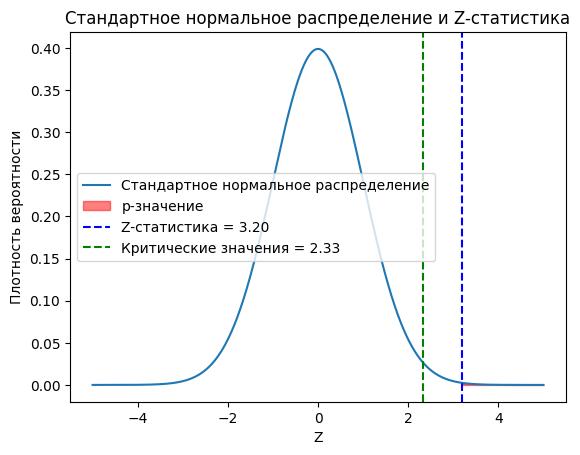

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

### Задача 2 (1 балл)

Даны три независимые выборки. Первая выборка объемом 35 наблюдений имеет выборочное среднее 10.2 и выборочную дисперсию 2.5. Вторая выборка объемом 30 наблюдений имеет выборочное среднее 9.8 и выборочную дисперсию 2.8. Третья выборка объемом 40 наблюдений имеет выборочное среднее 10.5 и выборочную дисперсию 3.0.

Проверьте гипотезу о том, что средние всех трех выборок равны, на уровне значимости 0.05.
Оцените статистическую значимость результатов и постройте доверительные интервалы c графиками для каждого из средних.

**Использовать попарное сравнение для получения результата**

Двухсторонний t-test для разности средних (дисперсия только выборочная, генеральная - неизвестна. Независимые случайные выборки), α=0.05.

H0: mu1 = mu2 = mu3

H1: mu1 != mu2 или mu1 != mu3 или mu2 != mu3

In [ ]:
# Данные задачи
n1 = 35                # Размер выборки 1
mu1 = 10.2             # Среднее выборки 1
sigma1 = np.sqrt(2.5)  # Стандартное отклонение выборки 1

n2 = 30                # Размер выборки 2
mu2 = 9.8              # Среднее выборки 2
sigma2 = np.sqrt(2.8)  # Стандартное отклонение выборки 2

n3 = 40                # Размер выборки 3
mu3 = 10.5             # Среднее выборки 3
sigma3 = np.sqrt(3)    # Стандартное отклонение выборки 3

alpha = 0.05           # Уровень значимости

In [ ]:
tester12 = TTester(n1 + n2 - 2, Sides.COMMON, alpha)
stats12 = tester12.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 2.6381
Стандартная ошибка (SE): 0.4041
Cтатистика: 0.9898
Область внутри критических значений: [-1.9983, 1.9983]
p-значение: 0.32605
Не отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-0.4076, 1.2076]


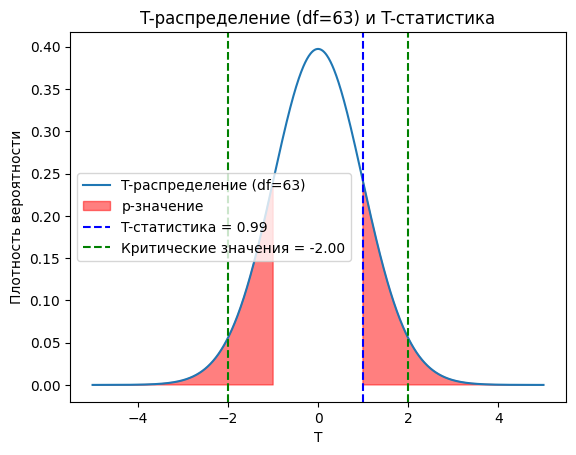

In [ ]:
printer12 = TTestingPrinter(n1 + n2 - 2)
printer12.show(stats12[1], stats12[2])

In [ ]:
tester13 = TTester(n1 + n3 - 2, Sides.COMMON, alpha)
stats13 = tester13.get_stats_for_mean_diff(n1, mu1, sigma1, n3, mu3, sigma3)

Объединенная выборочная дисперсия (sp^2): 2.7671
Стандартная ошибка (SE): 0.3850
Cтатистика: -0.7792
Область внутри критических значений: [-1.9930, 1.9930]
p-значение: 0.43839
Не отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-1.0673, 0.4673]


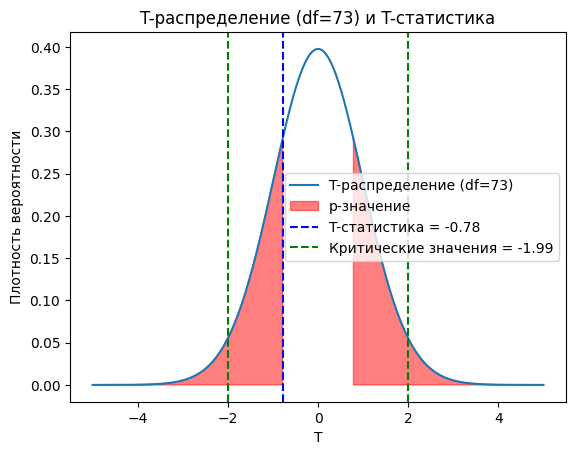

In [ ]:
printer13 = TTestingPrinter(n1 + n3 - 2)
printer13.show(stats13[1], stats13[2])

In [ ]:
tester23 = TTester(n2 + n3 - 2, Sides.COMMON, alpha)
stats23 = tester23.get_stats_for_mean_diff(n2, mu2, sigma2, n3, mu3, sigma3)

Объединенная выборочная дисперсия (sp^2): 2.9147
Стандартная ошибка (SE): 0.4123
Cтатистика: -1.6976
Область внутри критических значений: [-1.9955, 1.9955]
p-значение: 0.09415
Не отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-1.5228, 0.1228]


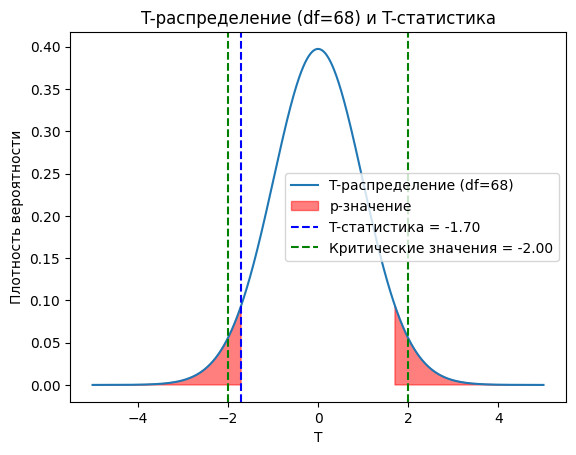

In [ ]:
printer23 = TTestingPrinter(n2 + n3 - 2)
printer23.show(stats23[1], stats23[2])

In [ ]:
if stats12[0] or stats13[0] or stats23[0]:
  print('Нельзя сказать, что средние трех выборок равны.')
else:
  print('Статистически значимых различий в средних выборок выявлено не было.')

Статистически значимых различий в средних выборок выявлено не было.


### Задача 3 (1 балл)

Тестирование параметра распределения Пуассона

Выборка из 60 наблюдений была получена из распределения Пуассона с неизвестным параметром. Известно, что среднее количество наблюдений в выборке равно 4.8.

Проверьте гипотезу о том, что параметр распределения Пуассона равен 5 против альтернативы, что он меньше 5. Используйте уровень значимости 0.05.
Вычислите p-значение и сделайте вывод о гипотезе.

Левосторонний z-test для среднего (дисперсия известна), α=0.05.

H0: mu = 5

H1: mu < 5

In [ ]:
# Данные задачи
mu0 = 5               # Гипотетическое среднее
sigma0 = np.sqrt(5)   # Cтандартное отклонение
n = 60                # Размер выборки
mu = 4.8              # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.LEFT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.2887
Статистика: -0.6928
Область внутри критических значений: [-1.6449, inf]
p-значение: 0.24421
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [0.4174, 9.1826]


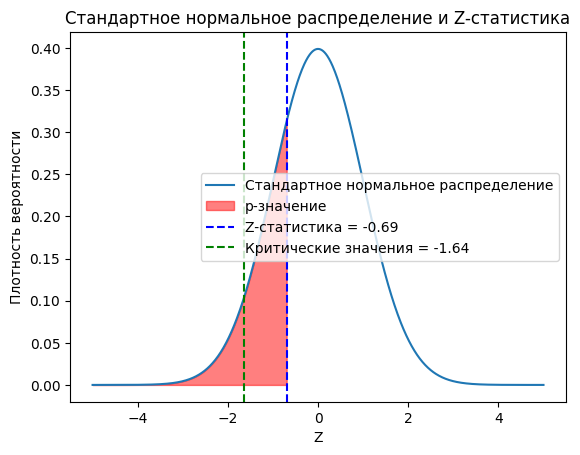

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

### Задача 4 (1 балл)

Компания заявляет, что среднее время работы их нового аккумулятора составляет 100 часов. Независимая лаборатория протестировала 25 случайно выбранных аккумуляторов и получила среднее время работы 95 часов при стандартном отклонении 10 часов. Можно ли на уровне значимости 1% утверждать, что реальное среднее время работы аккумуляторов меньше заявленного?

Левосторонний t-test для среднего, α=0.01.

H0: mu = 100

H1: mu < 100

In [ ]:
# Данные задачи
mu0 = 100         # Гипотетическое среднее
sigma0 = 10       # Стандартное отклонение
n = 25            # Размер выборки
mu = 95           # Выборочное среднее
alpha = 0.01      # Уровень значимости

tester = TTester(n-1, Sides.LEFT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 2.0000
Статистика: -2.5000
Область внутри критических значений: [-2.4922, inf]
p-значение: 0.00983
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [67.0306, 122.9694]


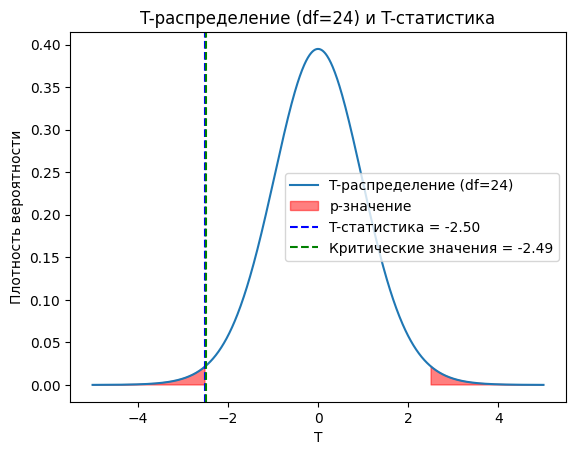

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

### Задача 5 (1 балл)

В ходе медицинского исследования сравнивается эффективность нового препарата для снижения артериального давления с существующим. Первой группе из 30 пациентов назначают новый препарат, и среднее снижение давления составляет 8 мм рт. ст. со стандартным отклонением 2 мм рт. ст. Второй группе из 30 пациентов дают существующий препарат, и среднее снижение составляет 6 мм рт. ст. со стандартным отклонением 3 мм рт. ст. Является ли новый препарат более эффективным на уровне значимости 5%?

Правосторонний t-test для разности средних, α=0.05.

H0: mu1 = mu2

H1: mu1 > mu2

In [ ]:
# Данные задачи
n1 = 30                # Размер выборки 1
mu1 = 8                # Среднее выборки 1
sigma1 = 2             # Стандартное отклонение выборки 1

n2 = 30                # Размер выборки 2
mu2 = 6                # Среднее выборки 2
sigma2 = 3             # Стандартное отклонение выборки 2

alpha = 0.05

In [ ]:
tester = TTester(n1 + n2 - 1, Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 6.5000
Стандартная ошибка (SE): 0.6583
Cтатистика: 3.0382
Область внутри критических значений: [-inf, 1.6711]
p-значение: 0.00177
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [0.6828, 3.3172]


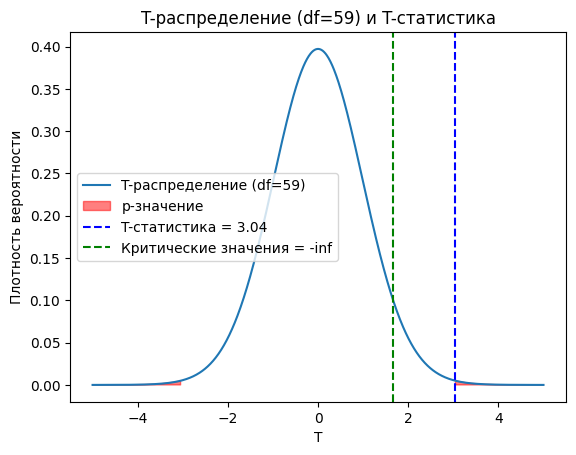

In [ ]:
printer = TTestingPrinter(n1 + n2 - 1)
printer.show(stats[1], stats[2])

### Задача 6 (1 балл)

В университете внедрили новую методику преподавания математики и хотят оценить ее влияние на успеваемость студентов. Средний балл по математике в предыдущие годы был 75. После внедрения методики группа из 50 студентов получила средний балл 78 с стандартным отклонением 5. Проверить на уровне значимости 1%, улучшилась ли успеваемость студентов.

Правосторонний t-тест для среднего, α=0.01.

H0: μ=75

H1: μ>75

In [ ]:
# Данные задачи
mu0 = 75          # Гипотетическое среднее
sigma0 = 5        # Стандартное отклонение
n = 50            # Размер выборки
mu = 78           # Выборочное среднее
alpha = 0.01      # Уровень значимости

tester = TTester(n-1, Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.7071
Статистика: 4.2426
Область внутри критических значений: [-inf, 2.4049]
p-значение: 0.00005
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [64.6002, 91.3998]


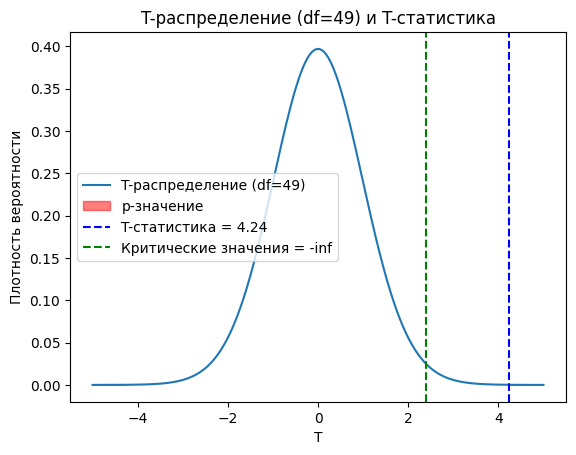

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

### Задача 7 (1 балл)

Производитель утверждает, что его новый процессор работает на 20% быстрее предыдущей модели. Для проверки этого заявления были протестированы 40 новых и 40 старых процессоров. Новые процессоры в среднем выполняли задачу за 8 секунд с стандартным отклонением 1 секунда, старые — за 10 секунд с стандартным отклонением 1,5 секунды. Соответствует ли утверждение производителя действительности на уровне значимости 2%?

Двухсторонний t-test для разности средних, α=0.02.

H0: mu1 = 0.8 * mu2

H1: mu1 != 0.8 * mu2

In [ ]:
# Данные задачи
n1 = 40                # Размер выборки 1
mu1 = 8                # Среднее выборки 1
sigma1 = 1             # Стандартное отклонение выборки 1

n2 = 40                # Размер выборки 2
mu2 = 10 * 0.8         # Среднее выборки 2
sigma2 = 1.5           # Стандартное отклонение выборки 2

alpha = 0.02

In [ ]:
tester = TTester(n1 + n2 - 1, Sides.COMMON, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 1.6250
Стандартная ошибка (SE): 0.2850
Cтатистика: 0.0000
Область внутри критических значений: [-2.3745, 2.3745]
p-значение: 1.00000
Не отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-0.6768, 0.6768]


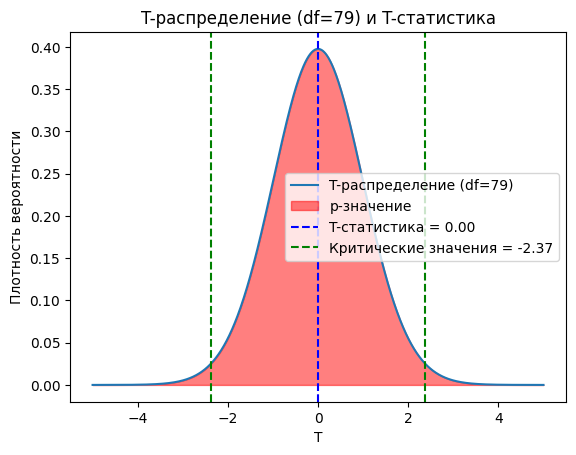

In [ ]:
printer = TTestingPrinter(n1 + n2 - 1)
printer.show(stats[1], stats[2])

### Задача 8 (1 балл)

После введения новых экологических стандартов исследователь хочет определить, снизился ли уровень загрязнения воздуха в городе. До введения стандартов средняя концентрация вредных веществ составляла 50 мкг/м³. Через год после внедрения было проведено 36 измерений, и средняя концентрация составила 47 мкг/м³ со стандартным отклонением 4 мкг/м³. Можно ли на уровне значимости 5% считать, что уровень загрязнения воздуха снизился?

Левосторонний t-тест для среднего, α=0.01.

H0: μ = 50

H1: μ < 50

In [ ]:
# Данные задачи
mu0 = 50          # Гипотетическое среднее
sigma0 = 4        # Стандартное отклонение
n = 36            # Размер выборки
mu = 47           # Выборочное среднее
alpha = 0.01      # Уровень значимости

tester = TTester(n-1, Sides.LEFT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.6667
Статистика: -4.5000
Область внутри критических значений: [-2.4377, inf]
p-значение: 0.00004
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [36.1048, 57.8952]


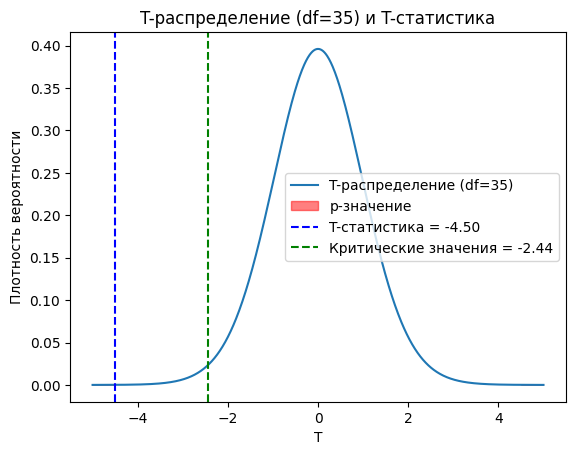

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

### Задача 9 (1 балл)

В школе проводят эксперимент, чтобы выяснить, влияет ли дополнительное занятие по чтению на скорость чтения учеников. Учеников случайным образом разделили на две группы по 20 человек. Первая группа занималась по стандартной программе и показала среднюю скорость чтения 150 слов в минуту со стандартным отклонением 15 слов. Вторая группа посещала дополнительные занятия и показала среднюю скорость 160 слов в минуту со стандартным отклонением 10 слов. Является ли разница в скоростях статистически значимой на уровне значимости 5%?

Двухсторонний t-test для разности средних, α=0.05.

H0: mu1 = mu2

H1: mu1 != mu2

In [ ]:
# Данные задачи (поменяем группы местами, чтобы первая оказалась целевой)
n1 = 20                # Размер выборки 1
mu1 = 160              # Среднее выборки 1
sigma1 = 10            # Стандартное отклонение выборки 1

n2 = 20                # Размер выборки 2
mu2 = 150              # Среднее выборки 2
sigma2 = 15            # Стандартное отклонение выборки 2

alpha = 0.05

In [ ]:
tester = TTester(n1 + n2 - 2, Sides.COMMON, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 162.5000
Стандартная ошибка (SE): 4.0311
Cтатистика: 2.4807
Область внутри критических значений: [-2.0244, 2.0244]
p-значение: 0.01766
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [1.8394, 18.1606]


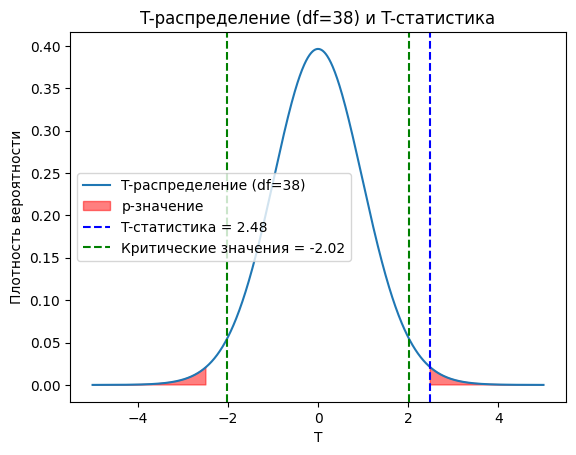

In [ ]:
printer = TTestingPrinter(n1 + n2 - 2)
printer.show(stats[1], stats[2])

### Задача 10 (1 балл)

Автомобильная компания хочет определить, влияет ли новый тип топлива на эффективность расхода топлива. В тесте участвовали 30 автомобилей, использующих обычное топливо, и 30 автомобилей на новом топливе. Средний расход для обычного топлива составил 8 литров на 100 км с стандартным отклонением 0,5 литра, для нового топлива — 7,5 литров на 100 км с стандартным отклонением 0,4 литра. Проверьте на уровне значимости 1%, улучшает ли новый тип топлива эффективность.

Левосторонний t-test для разности средних, α=0.01.

H0: mu1 = mu2

H1: mu1 < mu2

In [ ]:
# Данные задачи (поменяем группы местами, чтобы первая оказалась целевой)
n1 = 30                # Размер выборки 1
mu1 = 7.5              # Среднее выборки 1
sigma1 = 0.4           # Стандартное отклонение выборки 1

n2 = 30                # Размер выборки 2
mu2 = 8                # Среднее выборки 2
sigma2 = 0.5           # Стандартное отклонение выборки 2

alpha = 0.01

In [ ]:
tester = TTester(n1 + n2 - 2, Sides.LEFT, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 0.2050
Стандартная ошибка (SE): 0.1169
Cтатистика: -4.2770
Область внутри критических значений: [-2.3924, inf]
p-значение: 0.00004
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-0.8114, -0.1886]


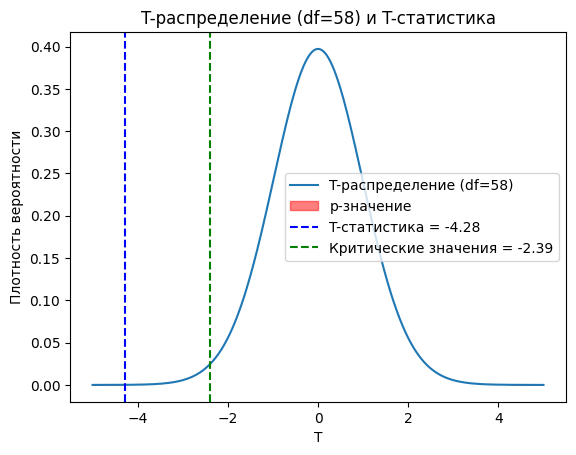

In [ ]:
printer = TTestingPrinter(n1 + n2 - 2)
printer.show(stats[1], stats[2])

### Задача 11 (1 балл)

В исследовании психологии изучается влияние медитации на уровень стресса. Уровень стресса измеряется по шкале от 0 до 100. До начала программы медитации у группы из 25 участников средний уровень стресса был 70 с стандартным отклонением 8. После программы средний уровень снизился до 65 с стандартным отклонением 7. Является ли снижение уровня стресса статистически значимым на уровне значимости 5%?

Левосторонний t-test для разности средних, α=0.05.

H0: mu1 = mu2

H1: mu1 < mu2

In [ ]:
# Данные задачи (поменяем группы местами, чтобы первая оказалась целевой)
n1 = 25                # Размер выборки 1
mu1 = 65               # Среднее выборки 1
sigma1 = 7             # Стандартное отклонение выборки 1

n2 = 25                # Размер выборки 2
mu2 = 70               # Среднее выборки 2
sigma2 = 8             # Стандартное отклонение выборки 2

alpha = 0.05

In [ ]:
tester = TTester(n1 + n2 - 2, Sides.LEFT, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 56.5000
Стандартная ошибка (SE): 2.1260
Cтатистика: -2.3518
Область внутри критических значений: [-1.6772, inf]
p-значение: 0.01142
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [-9.2747, -0.7253]


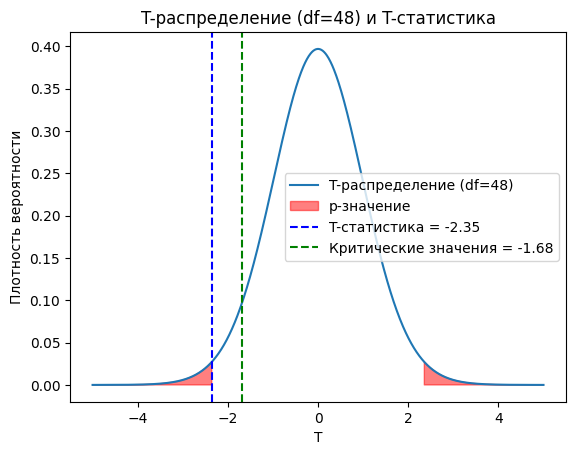

In [ ]:
printer = TTestingPrinter(n1 + n2 - 2)
printer.show(stats[1], stats[2])

### Задача 12 (1 балл)

Компания по производству напитков изменила рецепт своего продукта и хочет определить, повлияло ли это на предпочтения потребителей. В тестировании участвовали 200 человек, из которых 110 предпочли новый рецепт, а остальные остались нейтральны или выбрали старый. Можно ли на уровне значимости 1% утверждать, что большинство потребителей предпочитают новый рецепт?

Правосторонний z-test для доли (количество наблюдений достаточно большое), α=0.01.

H0: p = p0 = 0.5

H1: p != p0 = 0.5

In [ ]:
# Данные задачи
n = 200          # Размер выборки
n_true = 110     # Количество тех, кто предпочел новый рецепт
p0 = 0.5         # Критическая доля

alpha = 0.05

In [ ]:
tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_part(p0, n, n_true)

Выборочная пропорция (p̂): 0.5500
Стандартная ошибка (SE): 0.0354
Cтатистика: 1.4142
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.07865
Не отклоняем нулевую гипотезу.
Доверительный интервал для доли: [0.4807, 0.6193]


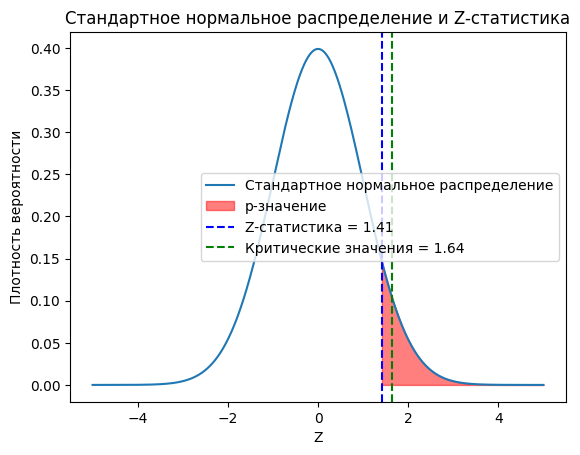

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

### Задача 13 (1 балл)

В ходе эксперимента изучается влияние нового удобрения на рост растений. Группе из 15 растений добавляли новое удобрение, и средний рост составил 25 см с стандартным отклонением 3 см. Контрольная группа из 15 растений без удобрения показала средний рост 22 см с стандартным отклонением 2,5 см. Проверить на уровне значимости 5%, является ли разница в росте статистически значимой.

Двухсторонний z-test для разности средних, α=0.05.

H0: mu1 = mu2

H1: mu1 != mu2

In [ ]:
# Данные задачи
n1 = 15                # Размер выборки 1
mu1 = 25               # Среднее выборки 1
sigma1 = 3             # Стандартное отклонение выборки 1

n2 = 15                # Размер выборки 2
mu2 = 22               # Среднее выборки 2
sigma2 = 2.5           # Стандартное отклонение выборки 2

alpha = 0.05

In [ ]:
tester = TTester(n1 + n2 - 2, Sides.COMMON, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 7.6250
Стандартная ошибка (SE): 1.0083
Cтатистика: 2.9753
Область внутри критических значений: [-2.0484, 2.0484]
p-значение: 0.00597
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [0.9346, 5.0654]


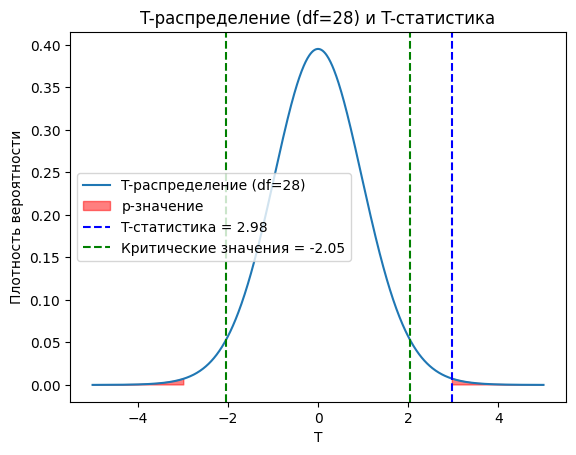

In [ ]:
printer = TTestingPrinter(n1 + n2 - 2)
printer.show(stats[1], stats[2])

### Задача 14 (5 баллов за все пункты)

Пункт 1. Компания внедряет новую программу обучения сотрудников с целью повышения производительности труда. Ранее средняя производительность составляла 50 единиц в день при стандартном отклонении 8 единиц. После года действия программы случайно выбранная выборка из 80 сотрудников показала среднюю производительность 52 единицы. Считаем, что стандартное отклонение осталось неизменным. Можно ли на основе этих данных утверждать, что программа обучения действительно повысила производительность, или наблюдаемый результат мог возникнуть случайно? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста (двусторонний, левосторонний или правосторонний) и проверьте нулевую гипотезу на уровнях значимости α = 1% и α = 5%.


---

Пункт 2. Решите пункт 1, если выборка состоит лишь из 5 сотрудников.


---

Пункт 3. Решите пункт 1 при условии, что стандартное отклонение увеличилось до 16 единиц.


---

Пункт 4. Решите пункт 1, если после внедрения программы средняя производительность составила 51 единицу.


---

Пункт 5. Решите пункт 1, если стандартное отклонение неизвестно, а выборка составила 25 сотрудников. Несмещённая оценка дисперсии выборки составила 64. Примите уровень значимости равным 5%.

#### Пункт 1

Правосторонний z-test для среднего (дано стандартное отклонение), α=0.01, 0.05.

H0: mu = 50

H1: mu1 > 50

При α=0.01:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 80                # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.01          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.8944
Статистика: 2.2361
Область внутри критических значений: [-inf, 2.3263]
p-значение: 0.01267
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [31.3934, 72.6066]


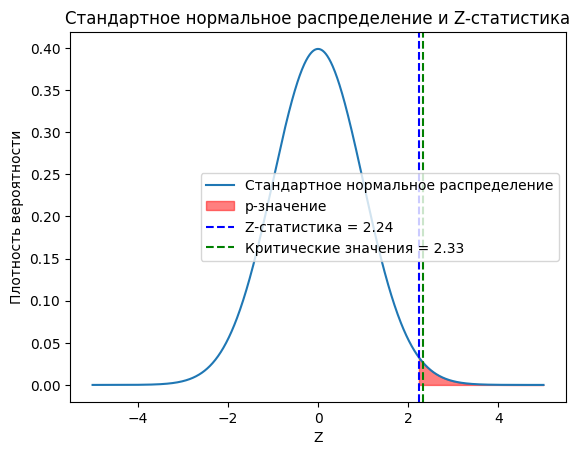

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

При α=0.05:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 80                # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.8944
Статистика: 2.2361
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.01267
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [36.3203, 67.6797]


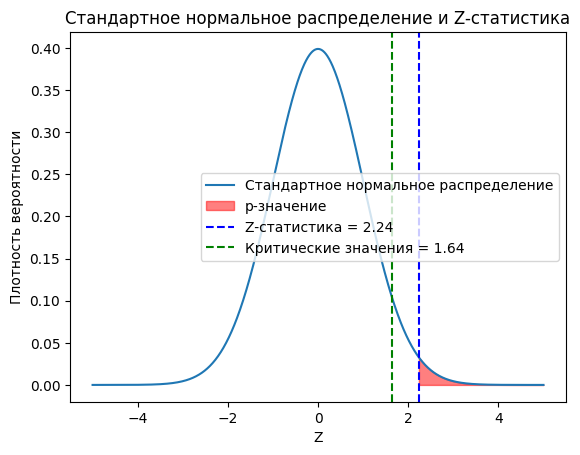

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 2

Правосторонний t-test для среднего (малое количество данных), α=0.01, 0.05.

H0: mu = 50

H1: mu > 50

При α=0.01:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 5                 # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.01          # Уровень значимости

tester = TTester(n-1, Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 3.5777
Статистика: 0.5590
Область внутри критических значений: [-inf, 3.7469]
p-значение: 0.30298
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [15.1672, 88.8328]


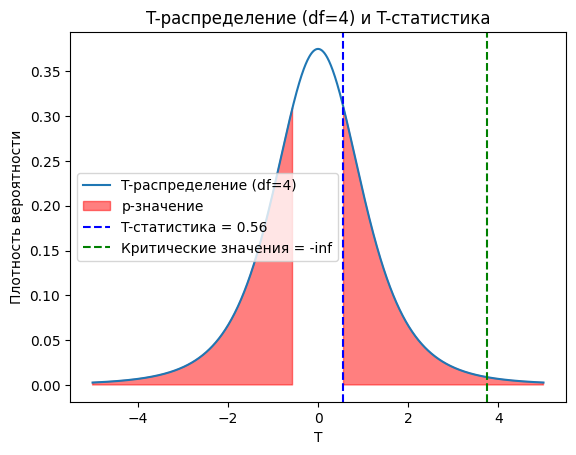

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

При α=0.05:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 5                 # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 3.5777
Статистика: 0.5590
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.28808
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [36.3203, 67.6797]


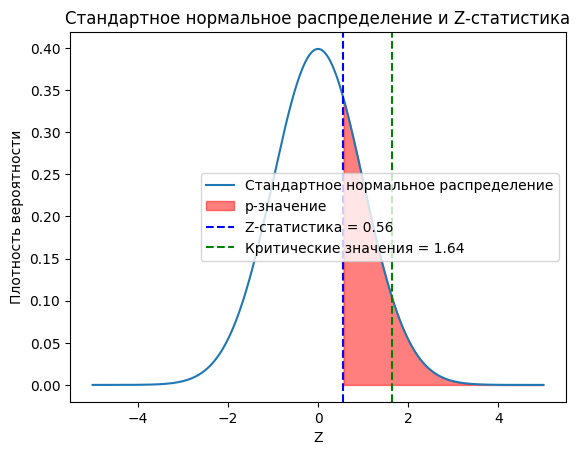

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 3

Правосторонний z-test для среднего (дано стандартное отклонение), α=0.01, 0.05.

H0: mu = 50

H1: mu > 50

При α=0.01:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 16           # Cтандартное отклонение
n = 80                # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.01          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 1.7889
Статистика: 1.1180
Область внутри критических значений: [-inf, 2.3263]
p-значение: 0.13178
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [10.7867, 93.2133]


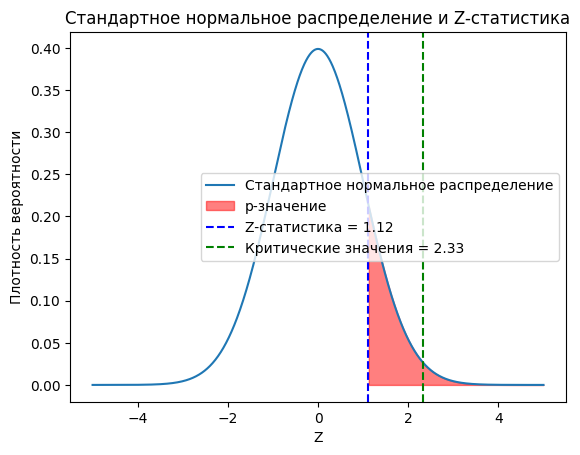

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

При α=0.05:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 16           # Cтандартное отклонение
n = 80                # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 1.7889
Статистика: 1.1180
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.13178
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [20.6406, 83.3594]


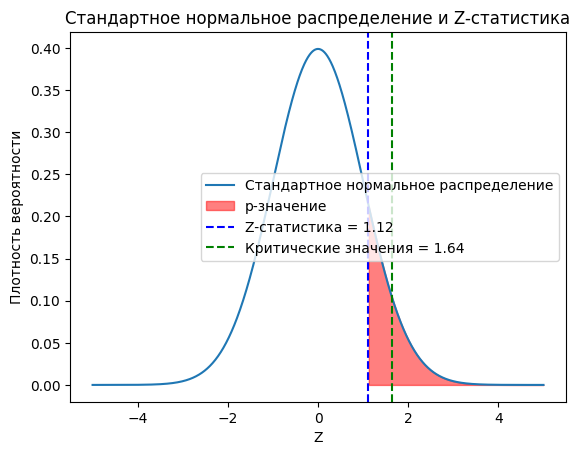

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 4

Правосторонний z-test для среднего (дано стандартное отклонение), α=0.01, 0.05.

H0: mu = 50

H1: mu > 50

При α=0.01:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 80                # Размер выборки
mu = 51               # Выборочное среднее
alpha = 0.01          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.8944
Статистика: 1.1180
Область внутри критических значений: [-inf, 2.3263]
p-значение: 0.13178
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [30.3934, 71.6066]


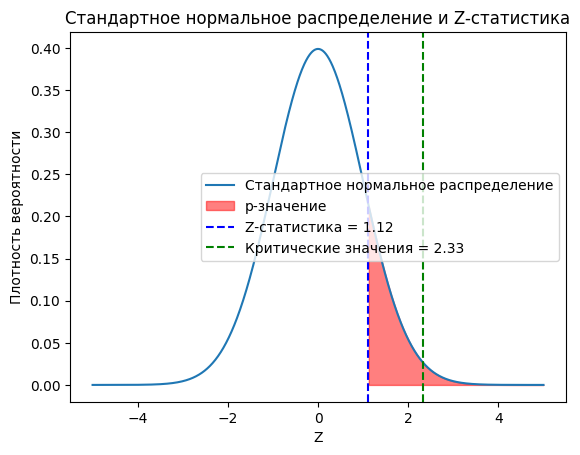

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

При α=0.05:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma0 = 8            # Cтандартное отклонение
n = 80                # Размер выборки
mu = 51               # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 0.8944
Статистика: 1.1180
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.13178
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [35.3203, 66.6797]


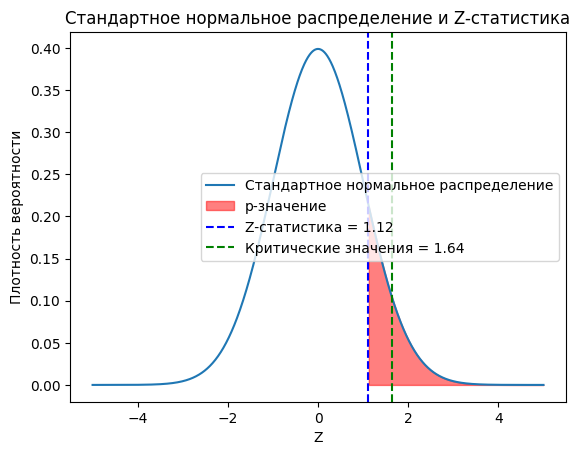

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 5

Правосторонний t-test для среднего (стандартное отклонение неизвестно, наблюдений мало), α=0.05.

H0: mu = 50

H1: mu > 50

При α=0.05:

In [ ]:
# Данные задачи
mu0 = 50              # Гипотетическое среднее
sigma = 8             # Cтандартное отклонение
n = 25                # Размер выборки
mu = 52               # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = TTester(n-1, Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 1.6000
Статистика: 1.2500
Область внутри критических значений: [-inf, 1.7109]
p-значение: 0.11168
Не отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [35.4888, 68.5112]


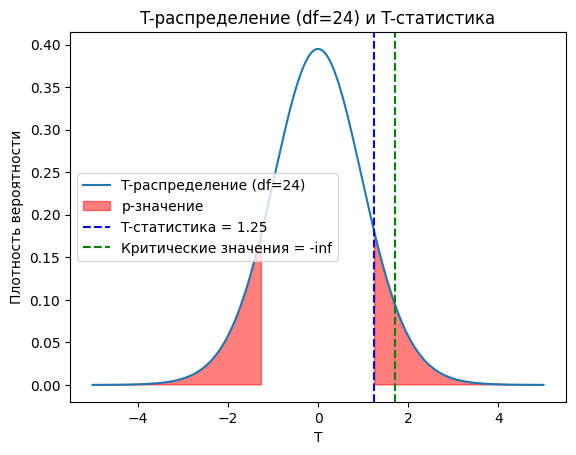

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

### Задача 15 (3 балла за все пункты)

Задача 1. Компания оценивает эффективность нового программного обеспечения для повышения производительности сотрудников. Перед установкой ПО среднее время выполнения определённой задачи у 60 сотрудников составляло 100 минут с известным стандартным отклонением 12 минут. После установки нового ПО среднее время выполнения той же задачи снизилось до 95 минут. Считаем, что стандартное отклонение осталось неизменным. Можно ли на уровне значимости α = 5% утверждать, что новое ПО действительно снижает время выполнения задачи? Сформулируйте нулевую и альтернативную гипотезы, определите тип теста и проверьте нулевую гипотезу.


---

Задача 2. Решите задачу 1, если стандартное отклонение после установки нового ПО неизвестно, а выборка составляет 25 сотрудников. По полученным данным несмещённая оценка дисперсии после установки ПО составляет 144 минуты².


---

Задача 3. Компания сравнивает эффективность двух независимых групп сотрудников: первая группа из 50 человек использует старое ПО, вторая группа из 50 человек — новое ПО. Среднее время выполнения задачи в первой группе составляет 100 минут со стандартным отклонением 12 минут, во второй группе — 95 минут со стандартным отклонением 12 минут. Можно ли на уровне значимости α = 5% утверждать, что новое ПО снижает время выполнения задачи по сравнению со старым?


---

Задача 4. Для оценки влияния обучающего курса на навыки сотрудников компания измеряет время выполнения задачи у 30 сотрудников до и после прохождения курса. Среднее время до обучения составляет 80 минут, после обучения — 75 минут. Известно, что стандартное отклонение разностей времени (до и после) составляет 5 минут. Можно ли на уровне значимости α = 1% утверждать, что обучение улучшило навыки сотрудников? Сформулируйте нулевую и альтернативную гипотезы и выберите подходящий статистический тест.


---

Задача 5. Решите задачу 4, если стандартное отклонение разностей времени неизвестно, а несмещённая оценка дисперсии разностей составляет 25 минут². Примите уровень значимости равным 1%.

#### Пункт 1

Правосторонний z-test для среднего (дано стандартное отклонение), α=0.05.

H0: mu = 95

H1: mu > 95

In [ ]:
# Данные задачи
mu0 = 95              # Гипотетическое среднее
sigma0 = 12           # Cтандартное отклонение
n = 60                # Размер выборки
mu = 100              # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 1.5492
Статистика: 3.2275
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.00062
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [76.4804, 123.5196]


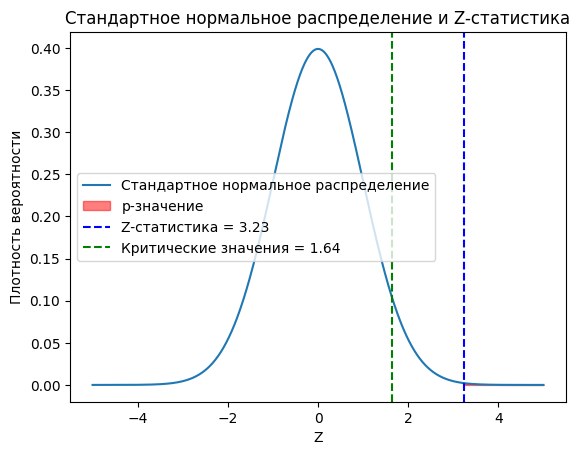

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 2

Правосторонний t-test для среднего, α=0.05.

H0: mu = 95

H1: mu > 95

In [ ]:
# Данные задачи
mu0 = 95              # Гипотетическое среднее
sigma0 = 12           # Cтандартное отклонение
n = 25                # Размер выборки
mu = 100              # Выборочное среднее
alpha = 0.05          # Уровень значимости

tester = TTester(n-1, Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean(mu0, n, mu, sigma0)

Стандартная ошибка (SE): 2.4000
Статистика: 2.0833
Область внутри критических значений: [-inf, 1.7109]
p-значение: 0.02402
Отклоняем нулевую гипотезу.
Доверительный интервал для среднего: [75.2332, 124.7668]


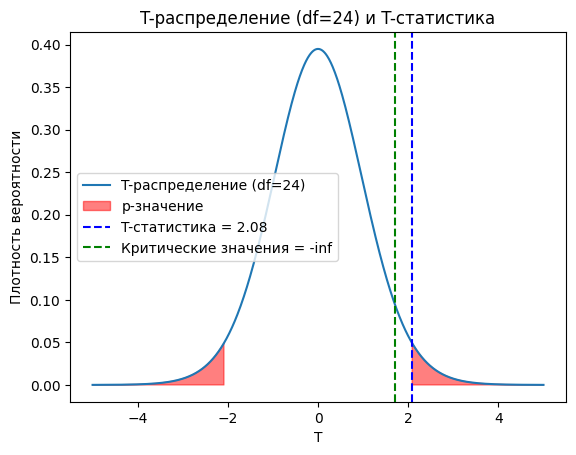

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

#### Пункт 3

Правосторонний z-test для разности средних, α=0.05.

H0: mu1 = mu2

H1: mu1 > mu2

In [ ]:
# Данные задачи
n1 = 50                # Размер выборки 1
mu1 = 100              # Среднее выборки 1
sigma1 = 12            # Стандартное отклонение выборки 1

n2 = 50                # Размер выборки 2
mu2 = 95               # Среднее выборки 2
sigma2 = 12            # Стандартное отклонение выборки 2

alpha = 0.05

In [ ]:
tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_mean_diff(n1, mu1, sigma1, n2, mu2, sigma2)

Объединенная выборочная дисперсия (sp^2): 144.0000
Стандартная ошибка (SE): 2.4000
Cтатистика: 2.0833
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.01861
Отклоняем нулевую гипотезу.
Доверительный интервал для разности средних: [0.2961, 9.7039]


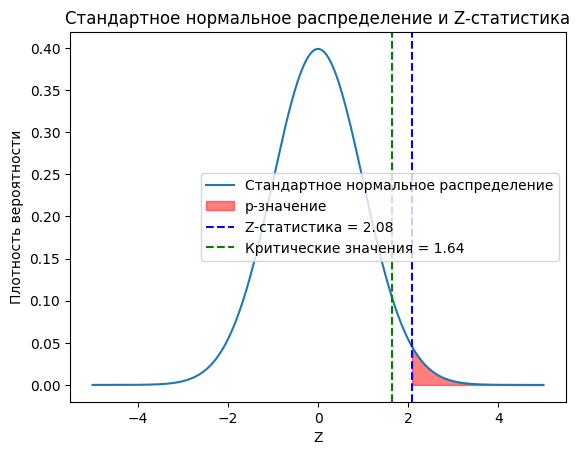

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 4

Левосторонний z-test для пар наблюдений, α=0.01.

H0: mu(diff) = 0

H1: mu(diff) < 0

In [ ]:
# Данные задачи
n = 30            # Количество пар наблюдений
mu_diff = -5      # Среднее значение разностей (после - до)
sigma_diff = 5    # Выборочное стандартное отклонение разностей
alpha = 0.01      # Уровень значимости

tester = ZTester(Sides.LEFT, alpha)
stats = tester.get_stats_for_pairs_diff(n, mu_diff, sigma_diff)

Стандартная ошибка (SE): 0.9129
Статистика: -5.4772
Область внутри критических значений: [-2.3263, inf]
p-значение: 0.00000
Отклоняем нулевую гипотезу.
Доверительный интервал для разности в парных наблюдениях: [-7.3514, -2.6486]


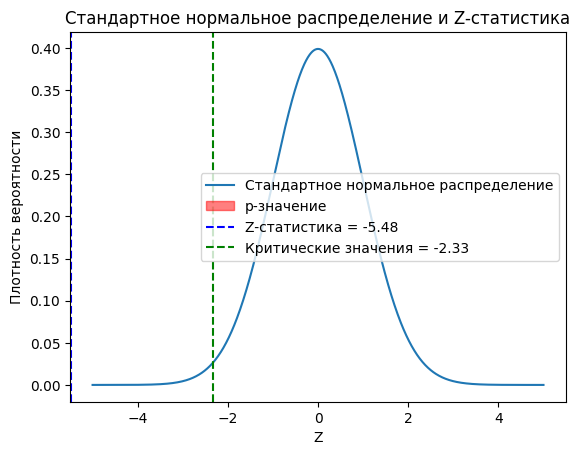

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

#### Пункт 5

Левосторонний t-test для пар наблюдений, α=0.01.

H0: mu(diff) = 0

H1: mu(diff) < 0

In [ ]:
# Данные задачи
n = 30            # Количество пар наблюдений
mu_diff = -5      # Среднее значение разностей (после - до)
sigma_diff = 5    # Выборочное стандартное отклонение разностей
alpha = 0.01      # Уровень значимости

tester = TTester(n-1, Sides.LEFT, alpha)
stats = tester.get_stats_for_pairs_diff(n, mu_diff, sigma_diff)

Стандартная ошибка (SE): 0.9129
Статистика: -5.4772
Область внутри критических значений: [-2.4620, inf]
p-значение: 0.00000
Отклоняем нулевую гипотезу.
Доверительный интервал для разности в парных наблюдениях: [-7.5162, -2.4838]


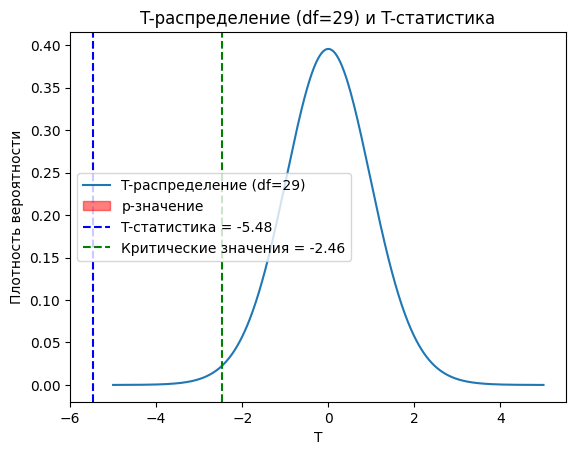

In [ ]:
printer = TTestingPrinter(n-1)
printer.show(stats[1], stats[2])

### Задача 16 (4 балла за все пункты)

Монетку подбросили n=150 раз. Из них выпало Y орлов. Вероятность выпадения орла равна p.

(a) При каких значениях Y вы отвергнете нулевую гипотезу H0:p=1/2 против односторонней альтернативы p>1/2 на уровне значимости α=0.05?

(b) Предположим, что на самом деле H0​ не выполняется, а выполняется H1​, и вероятность выпадения орла равна p=1/2+δ, где δ=1/10. При этом мы не знаем точное значение p, но действуем согласно нашему критерию. С какой вероятностью мы при этом отвергнем гипотезу H0​? Какова вероятность совершить ошибку второго рода (не отвергнуть H0​, когда H1​ истинна)?

(c) Решите ту же задачу для δ=1/100.

(d) Решите ту же задачу для δ=1/100 и n=1000.

#### Пункт а

In [ ]:
# Данные задачи
n = 150           # Общее число бросков
p0 = 1/2          # Гипотетическая вероятность выпадения числа орла
alpha = 0.05      # Уровень значимости

# Критическое значение Z
Z_alpha = st.norm.ppf(1 - alpha)
print(f"Критическое значение Z_alpha: {Z_alpha:.4f}")

# Стандартная ошибка
SE = np.sqrt(p0 * (1 - p0) / n)
print(f"Стандартная ошибка (SE): {SE:.4f}")

# Критическое значение выборочной пропорции
p_hat_critical = p0 + Z_alpha * SE
print(f"Критическая выборочная пропорция (p̂_кр): {p_hat_critical:.4f}")

# Критическое значение Y
Y_critical = p_hat_critical * n
print(f"Критическое значение Y_кр (до округления): {Y_critical:.4f}")

# Округляем вверх до ближайшего целого
Y_critical_int = int(np.ceil(Y_critical))
print(f"Критическое значение Y_кр (целое): {Y_critical_int}")

Критическое значение Z_alpha: 1.6449
Стандартная ошибка (SE): 0.0408
Критическая выборочная пропорция (p̂_кр): 0.5672
Критическое значение Y_кр (до округления): 85.0726
Критическое значение Y_кр (целое): 86


Проверим Y = 85 и 86 и убедимся, что 86 - первое целое значение, при котором отвергается гипотеза:

In [ ]:
tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_part(p0, n, Y_critical_int - 1)

Выборочная пропорция (p̂): 0.5667
Стандартная ошибка (SE): 0.0408
Cтатистика: 1.6330
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.05124
Не отклоняем нулевую гипотезу.
Доверительный интервал для доли: [0.4867, 0.6467]


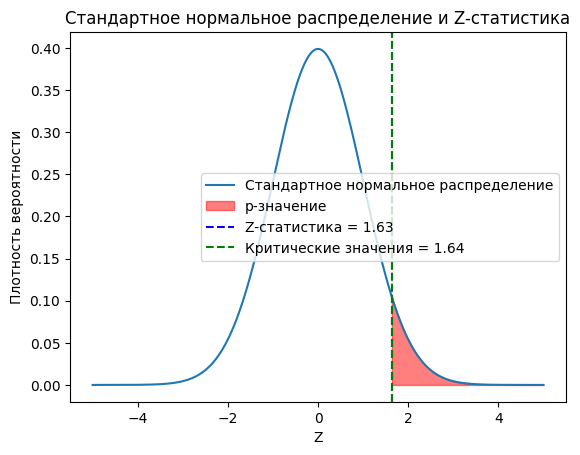

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

In [ ]:
tester = ZTester(Sides.RIGHT, alpha)
stats = tester.get_stats_for_part(p0, n, Y_critical_int)

Выборочная пропорция (p̂): 0.5733
Стандартная ошибка (SE): 0.0408
Cтатистика: 1.7963
Область внутри критических значений: [-inf, 1.6449]
p-значение: 0.03622
Отклоняем нулевую гипотезу.
Доверительный интервал для доли: [0.4933, 0.6533]


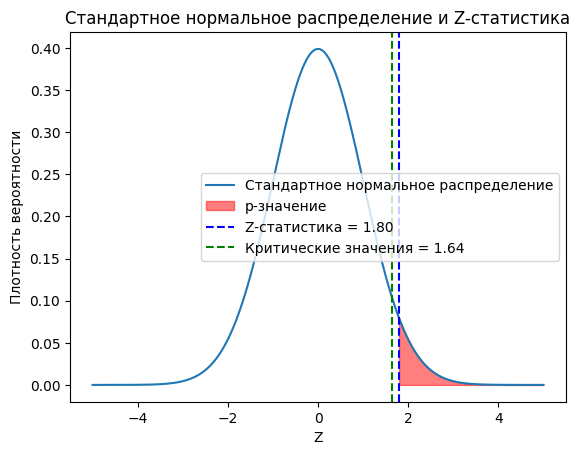

In [ ]:
printer = ZTestingPrinter()
printer.show(stats[1], stats[2])

Предположение верно.

#### Пункт б

In [ ]:
def show_test_power(p0, n, delta):
  p = p0 + delta
  se = np.sqrt(p0 * (1-p0) / n)
  z_alpha = st.norm.ppf(1 - alpha)
  z_beta = (p0 + se*z_alpha - p) / se
  power = 1 - st.norm.cdf(z_beta)
  beta = 1 - power
  print(f'Вероятность отклонить Н0: {power:.4f}')
  print(f'Вероятность совершить ошибку второго рода: {beta:.4f}\n')

In [ ]:
delta = 0.1
n = 150

show_test_power(p0, n, delta)

Вероятность отклонить Н0: 0.7895
Вероятность совершить ошибку второго рода: 0.2105



#### Пункт в

In [ ]:
delta = 0.01
n = 150

show_test_power(p0, n, delta)

Вероятность отклонить Н0: 0.0808
Вероятность совершить ошибку второго рода: 0.9192



#### Пункт г

In [ ]:
delta = 0.01
n = 1000

show_test_power(p0, n, delta)

Вероятность отклонить Н0: 0.1557
Вероятность совершить ошибку второго рода: 0.8443

